# Carregando Bibliotecas

In [2]:
using JSON, DataFrames

# Escrevendo código das 3 heuristicas

In [3]:
function read_instance(path)
    d = JSON.parsefile(path)
    jobs = DataFrame(
        job      = String.(d["jobs"]),
        release  = Int.(d["release"]),
        duration = Int.(d["duration"]),
        due      = Int.(d["due"]),
    )
    return jobs, String(d["name"])
end

function schedule_jobs(jobs::DataFrame, seq)
    rel = Dict(jobs.job .=> jobs.release)
    dur = Dict(jobs.job .=> jobs.duration)
    due = Dict(jobs.job .=> jobs.due)
    sched = DataFrame(job=String[], start=Float64[], finish=Float64[], past=Float64[])
    t = 0.0
    for j in seq
        t = max(t, rel[j])
        s = t; t += dur[j]; f = t
        push!(sched, (j, s, f, max(0.0, f - due[j])))
    end
    return sched
end

schedule_jobs (generic function with 1 method)

# Testando em 1 instancia

In [4]:
INSTDIR = raw"C:\Users\Saidk\OneDrive\Desktop\Mestrado\optimization2026\materiais\AULA06\machinescheduling_instances"

jobs, nome = read_instance(joinpath(INSTDIR, "inst_book.json"))
fifo = sum(schedule_jobs(jobs, sort(jobs, :release;  alg=MergeSort).job).past)
edd  = sum(schedule_jobs(jobs, sort(jobs, :due;      alg=MergeSort).job).past)
spt  = sum(schedule_jobs(jobs, sort(jobs, :duration; alg=MergeSort).job).past)
println("$nome:  FIFO=$fifo  EDD=$edd  SPT=$spt")

inst_book:  FIFO=31.0  EDD=27.0  SPT=51.0


# Rodando em Todas as Instâncias

In [5]:
paths = filter(f -> endswith(f, ".json"), readdir(INSTDIR; join=true))

for path in sort(paths)
    jobs, nome = read_instance(path)
    fifo = sum(schedule_jobs(jobs, sort(jobs, :release;  alg=MergeSort).job).past)
    edd  = sum(schedule_jobs(jobs, sort(jobs, :due;      alg=MergeSort).job).past)
    spt  = sum(schedule_jobs(jobs, sort(jobs, :duration; alg=MergeSort).job).past)
    println("$nome:  FIFO=$fifo  EDD=$edd  SPT=$spt")
end

inst_book:  FIFO=31.0  EDD=27.0  SPT=51.0
inst_n05_s01:  FIFO=9.0  EDD=7.0  SPT=54.0
inst_n05_s02:  FIFO=19.0  EDD=15.0  SPT=15.0
inst_n05_s03:  FIFO=4.0  EDD=3.0  SPT=20.0
inst_n07_s01:  FIFO=42.0  EDD=58.0  SPT=99.0
inst_n07_s02:  FIFO=40.0  EDD=31.0  SPT=77.0
inst_n07_s03:  FIFO=36.0  EDD=30.0  SPT=56.0
inst_n09_s01:  FIFO=38.0  EDD=29.0  SPT=62.0
inst_n09_s02:  FIFO=83.0  EDD=94.0  SPT=64.0
inst_n09_s03:  FIFO=47.0  EDD=39.0  SPT=43.0
inst_n11_s01:  FIFO=46.0  EDD=43.0  SPT=134.0
inst_n11_s02:  FIFO=98.0  EDD=113.0  SPT=229.0
inst_n11_s03:  FIFO=178.0  EDD=223.0  SPT=180.0
inst_n13_s01:  FIFO=116.0  EDD=146.0  SPT=213.0
inst_n13_s02:  FIFO=214.0  EDD=264.0  SPT=404.0
inst_n13_s03:  FIFO=82.0  EDD=103.0  SPT=277.0
inst_n15_s01:  FIFO=289.0  EDD=187.0  SPT=512.0
inst_n15_s02:  FIFO=250.0  EDD=236.0  SPT=507.0
inst_n15_s03:  FIFO=139.0  EDD=162.0  SPT=224.0
inst_n17_s01:  FIFO=379.0  EDD=275.0  SPT=696.0
inst_n17_s02:  FIFO=232.0  EDD=273.0  SPT=599.0
inst_n17_s03:  FIFO=189.0  EDD=22

# Agora desenvolvendo nosso modelo

In [9]:
using JuMP, HiGHS

function machine_schedule_milo(jobs::DataFrame; time_limit=60.0)
    J = jobs.job
    rel = Dict(J .=> jobs.release)
    dur = Dict(J .=> jobs.duration)
    due = Dict(J .=> jobs.due)
    bigM = maximum(jobs.release) + sum(jobs.duration)

    model = Model(HiGHS.Optimizer)
    set_optimizer_attribute(model, "time_limit", time_limit)

    @variable(model, start[J] >= 0)
    @variable(model, past[J] >= 0)
    pares = [(i,j) for i in J for j in J if i < j]
    @variable(model, z[pares], Bin)

    @constraint(model, [j in J], start[j] >= rel[j])
    @constraint(model, [j in J], past[j]  >= start[j] + dur[j] - due[j])

    for (i,j) in pares
        @constraint(model, start[j] >= start[i] + dur[i] - bigM*(1 - z[(i,j)]))
        @constraint(model, start[i] >= start[j] + dur[j] - bigM*z[(i,j)])
    end

    @objective(model, Min, sum(past[j] for j in J))
    optimize!(model)

    gap = relative_gap(model)

    sched = DataFrame(job=String[], start=Float64[], finish=Float64[], past=Float64[])
    for j in J
        s = value(start[j])
        push!(sched, (j, s, s + dur[j], value(past[j])))
    end
    sort!(sched, :start)
    return sched, objective_value(model), termination_status(model), gap
end

machine_schedule_milo (generic function with 1 method)

# Agora fazendo teste com 1 instancia

In [10]:
jobs, nome = read_instance(joinpath(INSTDIR, "inst_book.json"))
sched, obj, status = machine_schedule_milo(jobs)
println("$nome: ótimo = $obj  | status = $status")

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 56 rows; 35 cols; 147 nonzeros; 21 integer variables (21 binary)
Coefficient ranges:
  Matrix  [1e+00, 4e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 4e+01]
Presolving model
49 rows, 35 cols, 140 nonzeros 0s
28 rows, 35 cols, 77 nonzeros 0s
28 rows, 35 cols, 77 nonzeros 0s
Presolve reductions: rows 28(-28); columns 35(-0); nonzeros 77(-70) 

Solving MIP model with:
   28 rows
   35 cols (21 binary, 0 integer, 0 implied int., 14 continuous, 0 domain fixed)
   77 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z =>

# Agora roda todos e adiciona os resultados em uma tabela para comparação futura

In [11]:
resultados = DataFrame(
    instancia=String[], n=Int[], fifo=Int[], edd=Int[], spt=Int[],
    melhor=Int[], gap_pct=Float64[], tempo_s=Float64[], status=String[],
)

paths = filter(f -> endswith(f, ".json"), readdir(INSTDIR; join=true))

for (k, path) in enumerate(paths)
    jobs, nome = read_instance(path)
    println("[$k/$(length(paths))] resolvendo $nome (n=$(nrow(jobs)))...")

    fifo = sum(schedule_jobs(jobs, sort(jobs, :release;  alg=MergeSort).job).past)
    edd  = sum(schedule_jobs(jobs, sort(jobs, :due;      alg=MergeSort).job).past)
    spt  = sum(schedule_jobs(jobs, sort(jobs, :duration; alg=MergeSort).job).past)

    local sched, obj, st, gap
    tempo = @elapsed ((sched, obj, st, gap) = machine_schedule_milo(jobs; time_limit=60.0))

    push!(resultados, (nome, nrow(jobs), round(Int,fifo), round(Int,edd), round(Int,spt),
                       round(Int,obj), round(100*gap, digits=1), tempo, string(st)))
    println("    ✓ melhor=$(round(Int,obj))  gap=$(round(100*gap,digits=1))%  tempo=$(round(tempo,digits=2))s  [$st]")
    flush(stdout)
end

sort!(resultados, [:n, :instancia])
resultados

[1/31] resolvendo inst_book (n=7)...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 56 rows; 35 cols; 147 nonzeros; 21 integer variables (21 binary)
Coefficient ranges:
  Matrix  [1e+00, 4e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 4e+01]
Presolving model
49 rows, 35 cols, 140 nonzeros 0s
28 rows, 35 cols, 77 nonzeros 0s
28 rows, 35 cols, 77 nonzeros 0s
Presolve reductions: rows 28(-28); columns 35(-0); nonzeros 77(-70) 

Solving MIP model with:
   28 rows
   35 cols (21 binary, 0 integer, 0 implied int., 14 continuous, 0 domain fixed)
   77 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Tr

Row,instancia,n,fifo,edd,spt,melhor,gap_pct,tempo_s,status
,String,Int64,Int64,Int64,Int64,Int64,Float64,Float64,String
1,inst_n05_s01,5,9,7,54,7,0.0,0.0170485,OPTIMAL
2,inst_n05_s02,5,19,15,15,15,0.0,0.13486,OPTIMAL
3,inst_n05_s03,5,4,3,20,3,0.0,0.040332,OPTIMAL
4,inst_book,7,31,27,51,16,0.0,0.268553,OPTIMAL
5,inst_n07_s01,7,42,58,99,38,0.0,0.389811,OPTIMAL
6,inst_n07_s02,7,40,31,77,30,0.0,0.74504,OPTIMAL
7,inst_n07_s03,7,36,30,56,26,0.0,0.23912,OPTIMAL
8,inst_n09_s01,9,38,29,62,26,0.0,0.590663,OPTIMAL
9,inst_n09_s02,9,83,94,64,56,0.0,1.72,OPTIMAL


In [12]:
show(resultados, allrows=true)

31×9 DataFrame
 Row │ instancia     n      fifo   edd    spt    melhor  gap_pct  tempo_s      ⋯
     │ String        Int64  Int64  Int64  Int64  Int64   Float64  Float64      ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ inst_n05_s01      5      9      7     54       7      0.0   0.0170485   ⋯
   2 │ inst_n05_s02      5     19     15     15      15      0.0   0.13486
   3 │ inst_n05_s03      5      4      3     20       3      0.0   0.040332
   4 │ inst_book         7     31     27     51      16      0.0   0.268553
   5 │ inst_n07_s01      7     42     58     99      38      0.0   0.389811    ⋯
   6 │ inst_n07_s02      7     40     31     77      30      0.0   0.74504
   7 │ inst_n07_s03      7     36     30     56      26      0.0   0.23912
   8 │ inst_n09_s01      9     38     29     62      26      0.0   0.590663
   9 │ inst_n09_s02      9     83     94     64      56      0.0   1.72        ⋯
  10 │ inst_n09_s03      9     47     39     4

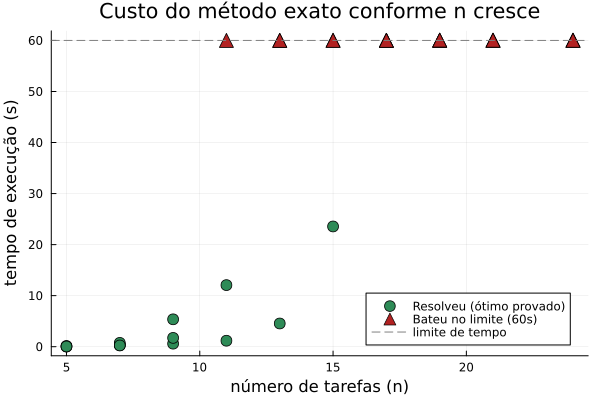

In [20]:
using Plots; gr()

# separa as instâncias por status
opt = filter(r -> r.status == "OPTIMAL",    resultados)
tl  = filter(r -> r.status == "TIME_LIMIT", resultados)

scatter(opt.n, opt.tempo_s;
    label="Resolveu (ótimo provado)", markershape=:circle, markersize=6, color=:seagreen)
scatter!(tl.n, tl.tempo_s;
    label="Bateu no limite (60s)", markershape=:utriangle, markersize=7, color=:firebrick)
hline!([60]; linestyle=:dash, color=:gray, label="limite de tempo")
xlabel!("número de tarefas (n)")
ylabel!("tempo de execução (s)")
title!("Custo do método exato conforme n cresce")

In [21]:
savefig("grafico_tempo.png")       # roda logo depois da Célula 8

"C:\\Users\\Saidk\\OneDrive\\Desktop\\Mestrado\\optimization2026\\alunos\\saidguimaraes12\\TRABALHO02\\(1) Machine Scheduling\\grafico_tempo.png"

In [15]:
using Pkg; Pkg.add("StatsPlots")
using StatsPlots

    Updating registry at `C:\Users\Saidk\.julia\registries\General.toml`
   Resolving package versions...
   Installed StatsFuns ─────────────── v2.2.0
   Installed HypergeometricFunctions ─ v0.3.28
   Installed Accessors ─────────────── v0.1.45
   Installed PDMats ────────────────── v0.11.40
   Installed OffsetArrays ──────────── v1.17.0
   Installed MuladdMacro ───────────── v0.2.6
   Installed StaticArrays ──────────── v1.9.18
   Installed Roots ─────────────────── v3.0.0
   Installed NearestNeighbors ──────── v0.4.27
   Installed Rmath_jll ─────────────── v0.5.1+0
   Installed StatsPlots ────────────── v0.15.8
   Installed Ratios ────────────────── v0.4.5
   Installed AbstractFFTs ──────────── v1.5.0
   Installed AbstractTrees ─────────── v0.4.5
   Installed Clustering ────────────── v0.15.8
   Installed ChainRulesCore ────────── v1.26.1
   Installed KernelDensity ─────────── v0.6.12
   Installed CompositionsBase ──────── v0.1.2
   Installed InverseFunctions ──────── v0.1.17
   Ins

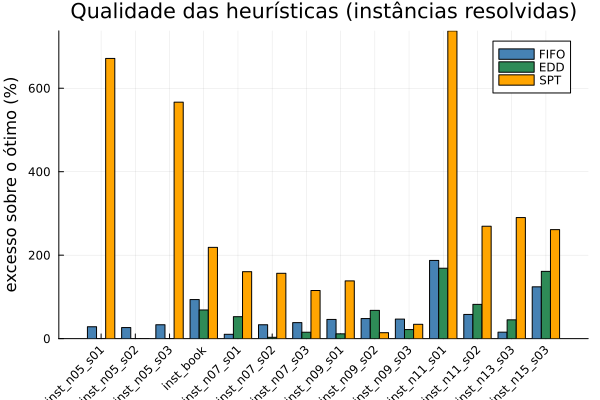

In [16]:
# só instâncias com ótimo comprovado
op = filter(r -> r.status == "OPTIMAL", resultados)

# excesso relativo de cada heurística sobre o ótimo, em %
# (quanto ela ficou ACIMA do ótimo; 0% = acertou o ótimo)
exc(h, o) = o == 0 ? 0.0 : 100 * (h - o) / o

fifo_exc = exc.(op.fifo, op.melhor)
edd_exc  = exc.(op.edd,  op.melhor)
spt_exc  = exc.(op.spt,  op.melhor)

groupedbar(
    [fifo_exc edd_exc spt_exc];
    label=["FIFO" "EDD" "SPT"],
    bar_position=:dodge,
    xticks=(1:nrow(op), op.instancia),
    xrotation=45,
    color=[:steelblue :seagreen :orange],
)
ylabel!("excesso sobre o ótimo (%)")
title!("Qualidade das heurísticas (instâncias resolvidas)")

In [19]:
savefig("grafico_heuristicas.png") # roda logo depois da Célula 9

"C:\\Users\\Saidk\\OneDrive\\Desktop\\Mestrado\\optimization2026\\alunos\\saidguimaraes12\\TRABALHO02\\(1) Machine Scheduling\\grafico_heuristicas.png"